## Lab 2 - Animal Image classification with CNN (due 17.04.2026)

### 0.1 Imports

In [73]:
import zipfile, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import csv
import time
from PIL import Image

import itertools
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score)

### 0.2 Read zip and laod dataset

In [2]:
BASE_DIR = Path.cwd().parent
zip_path = BASE_DIR / "data/lab_2/data.zip"
input_data_extraction_path = BASE_DIR / "data/lab_2/"

if not (input_data_extraction_path / "animals_dataset").exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(input_data_extraction_path)
else:
    print(f"{input_data_extraction_path / 'animals_dataset'} already there!")


/Users/sunsosun/Desktop/mini/ann/data/lab_2/animals_dataset already there!


In [3]:
src = input_data_extraction_path / "data"

if src.exists():    
    src.rename(input_data_extraction_path / "animals_dataset")

### 0.3. Setup train, test dirs

In [4]:
train_dir = input_data_extraction_path / "animals_dataset/train"
test_dir = input_data_extraction_path / "animals_dataset/test"


### 0.4. Basic EDA for train set (here i assume that test set is analogical and we dont have access for it)

Classes in train set: ['bears', 'elephants']
Train set class counts: {'bears': 200, 'elephants': 200}


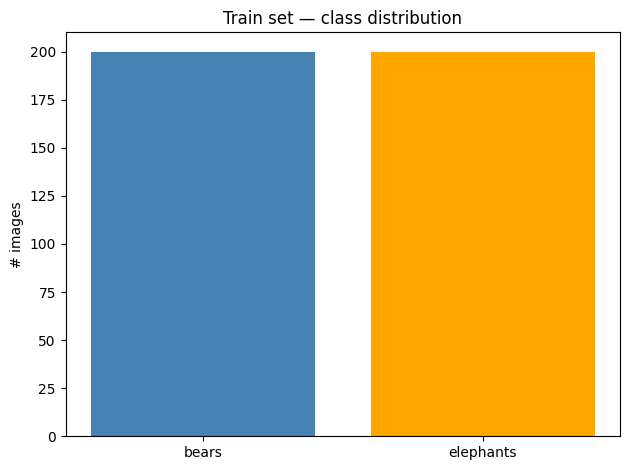

In [6]:
# Check distro of classes
classes = [d.name for d in train_dir.iterdir() if d.is_dir()]
print(f"Classes in train set: {classes}")

counts = {cls: len(list((train_dir / cls).iterdir())) for cls in classes}
print(f"Train set class counts: {counts}")

fig, ax = plt.subplots()
ax.bar(counts.keys(), counts.values(), color=["steelblue", "orange"])
ax.set_title("Train set — class distribution")
ax.set_ylabel("# images")
plt.tight_layout()
plt.show()

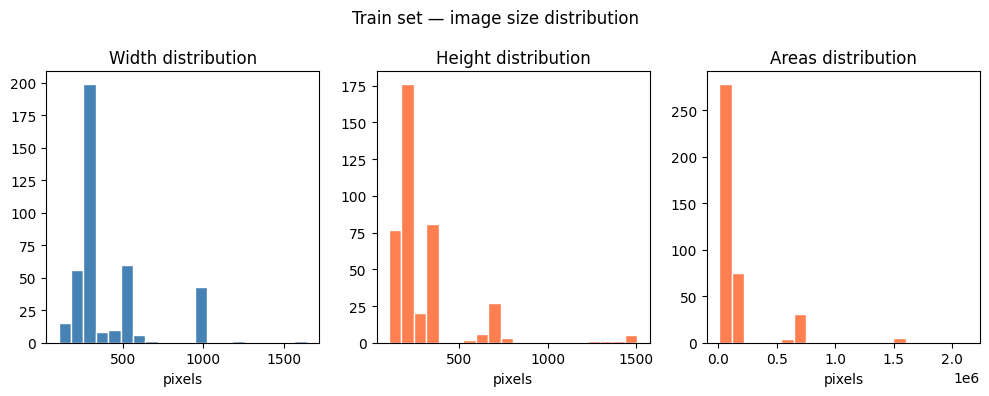

Width  — min: 104, max: 1638, mean: 395
Height — min: 104, max: 1506, mean: 289
Area — min: 10816, max: 2129400, mean: 161169


In [9]:
# Check img dimensions
widths, heights, areas = [], [], []
for cls in classes:
    for img_path in (train_dir / cls).iterdir():
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            areas.append(w*h)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].hist(widths, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("pixels")

axes[1].hist(heights, bins=20, color="coral", edgecolor="white")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("pixels")

axes[2].hist(areas, bins=20, color="coral", edgecolor="white")
axes[2].set_title("Areas distribution")
axes[2].set_xlabel("pixels")

plt.suptitle("Train set — image size distribution")
plt.tight_layout()
plt.show()

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")
print(f"Area — min: {min(areas)}, max: {max(areas)}, mean: {np.mean(areas):.0f}")

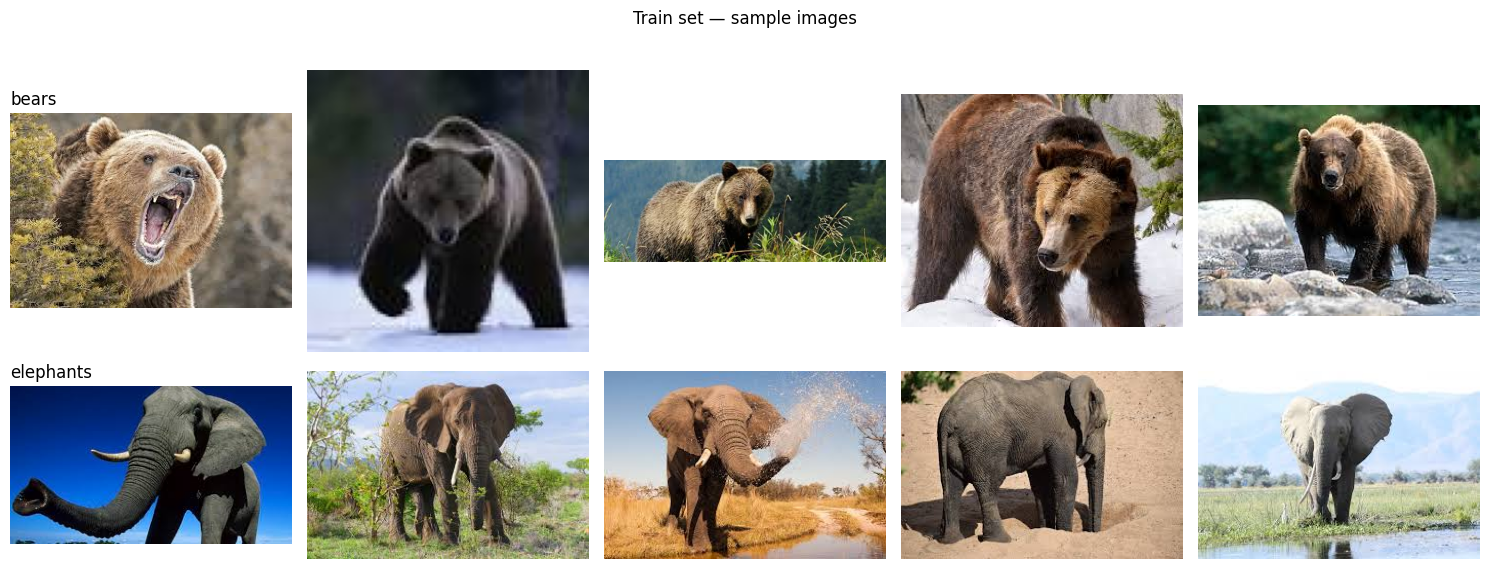

In [11]:
# Check images themselves
n_samples = 5
fig, axes = plt.subplots(len(classes), n_samples, figsize=(3 * n_samples, 3 * len(classes)))

for row, cls in enumerate(classes):
    imgs = sorted((train_dir / cls).iterdir())[:n_samples]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        ax.imshow(Image.open(img_path))
        ax.axis("off")
        if col == 0:
            ax.set_title(cls, fontsize=12, loc="left")
            
plt.suptitle("Train set — sample images", y=1.02)
plt.tight_layout()
plt.show()

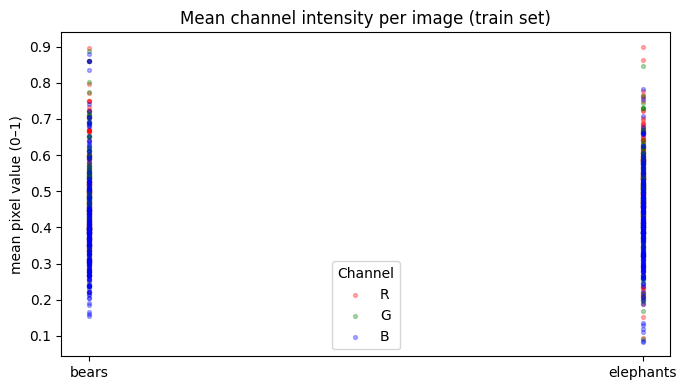

In [13]:
# pixels
TARGET_SIZE = (128, 128)

mean_pixels = {}
for cls in classes:
    pixels = []
    for img_path in (train_dir / cls).iterdir():
        arr = np.array(Image.open(img_path).convert("RGB").resize(TARGET_SIZE)) / 255.0
        pixels.append(arr.mean(axis=(0, 1)))   # mean R, G, B per image
    mean_pixels[cls] = np.array(pixels)

fig, ax = plt.subplots(figsize=(7, 4))
for i, (cls, vals) in enumerate(mean_pixels.items()):
    for c, color, label in zip(range(3), ["red", "green", "blue"], ["R", "G", "B"]):
        ax.scatter([i] * len(vals), vals[:, c], alpha=0.3, color=color, s=8,
                   label=label if i == 0 else "")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_title("Mean channel intensity per image (train set)")
ax.set_ylabel("mean pixel value (0–1)")
ax.legend(title="Channel")
plt.tight_layout()
plt.show()


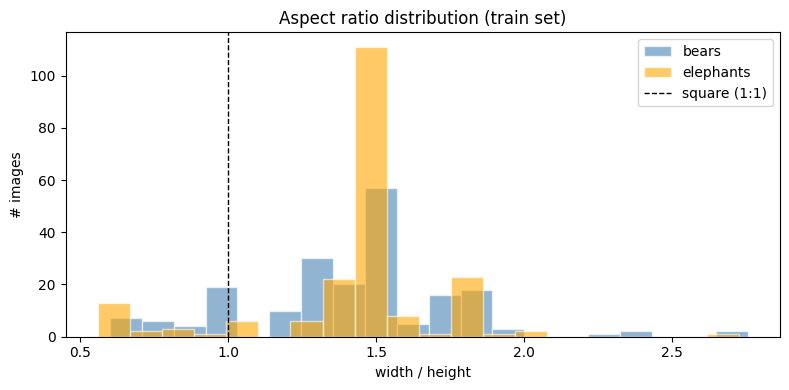

In [15]:
# Ratio width/height
fig, ax = plt.subplots(figsize=(8, 4))
for cls, color in zip(classes, ["steelblue", "orange"]):
    ratios = []
    for img_path in (train_dir / cls).iterdir():
        with Image.open(img_path) as img:
            w, h = img.size
            ratios.append(w / h)
    ax.hist(ratios, bins=20, alpha=0.6, label=cls, color=color, edgecolor="white")

ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="square (1:1)")
ax.set_title("Aspect ratio distribution (train set)")
ax.set_xlabel("width / height")
ax.set_ylabel("# images")
ax.legend()
plt.tight_layout()
plt.show()


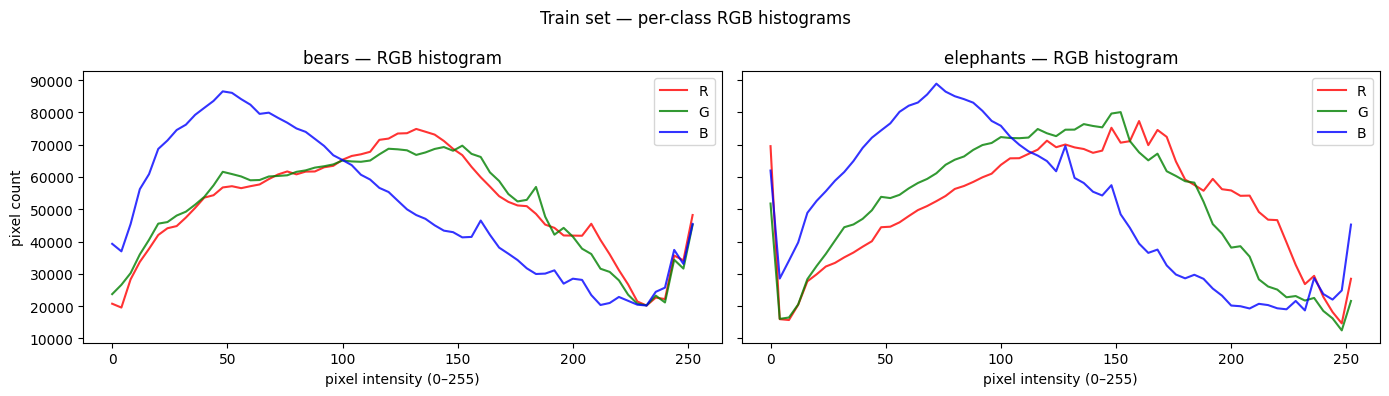

In [20]:
# RGB per class
fig, axes = plt.subplots(1, len(classes), figsize=(7 * len(classes), 4), sharey=True)

for ax, cls in zip(axes, classes):
    r_all, g_all, b_all = [], [], []
    for img_path in (train_dir / cls).iterdir():
        arr = np.array(Image.open(img_path).convert("RGB").resize(TARGET_SIZE))
        r_all.append(arr[:, :, 0].ravel())
        g_all.append(arr[:, :, 1].ravel())
        b_all.append(arr[:, :, 2].ravel())

    r_all = np.concatenate(r_all)
    g_all = np.concatenate(g_all)
    b_all = np.concatenate(b_all)

    bins = np.arange(0, 257, 4)
    ax.plot(bins[:-1], np.histogram(r_all, bins=bins)[0], color="red",   alpha=0.8, label="R")
    ax.plot(bins[:-1], np.histogram(g_all, bins=bins)[0], color="green", alpha=0.8, label="G")
    ax.plot(bins[:-1], np.histogram(b_all, bins=bins)[0], color="blue",  alpha=0.8, label="B")
    ax.set_title(f"{cls} — RGB histogram")
    ax.set_xlabel("pixel intensity (0–255)")
    ax.legend()

axes[0].set_ylabel("pixel count")
plt.suptitle("Train set — per-class RGB histograms")
plt.tight_layout()
plt.show()


After EDA I would like to do transformations of images for normalization before feeding to CNNs but tasks explicitely state which transformations to do in each, so I will do them gradually within the tasks 

### Q1. Baseline Linear Classifier (Flatten → Linear → Softmax).
Resize images to 128×128, normalize RGB, flatten, and train a single Linear layer → num_classes with CrossEntropyLoss. Report top‑1 accuracy on the validation split.    

In [35]:
# configs for splitting and img normalization
SEED = 42
IMG_SIZE = 128 # resize img to 128*128
BATCH_SIZE = 64
VAL_FRAC = 0.2
NUM_CLASSES = 2

# from ImageNet dataset stats
MEAN_LIST = [0.485, 0.456, 0.406] 
STD_LIST = [0.229, 0.224, 0.225]

# configs for training
EPOCHS = 10
LR = 1e-3

In [25]:
torch.manual_seed(SEED)

# transformation pipeline for input
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN_LIST, std=STD_LIST),
])

In [26]:
# get datasets
full_train_ds = ImageFolder(root=str(train_dir), transform=transform)
test_ds = ImageFolder(root=str(test_dir), transform=transform)

# split full train to train and val
n_val = int(len(full_train_ds) * VAL_FRAC)
n_train = len(full_train_ds) - n_val

train_ds, val_ds = random_split(full_train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

# loaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [32]:
class LinearClassifier(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3*img_size*img_size, num_classes)
    def forward(self,x):
        return self.linear(self.flatten(x))

In [34]:
model = LinearClassifier()
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

LinearClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=49152, out_features=2, bias=True)
)
Parameters: 98,306


In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total

In [37]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.4f} | "
          f"val loss {vl_loss:.4f}  acc {vl_acc:.4f}")


Epoch  1/10 | train loss 6.0049  acc 0.5719 | val loss 6.7385  acc 0.5750
Epoch  2/10 | train loss 4.4554  acc 0.6969 | val loss 5.2709  acc 0.6250
Epoch  3/10 | train loss 3.2559  acc 0.7562 | val loss 8.1238  acc 0.5875
Epoch  4/10 | train loss 2.5902  acc 0.7688 | val loss 3.5813  acc 0.7125
Epoch  5/10 | train loss 1.7337  acc 0.8375 | val loss 4.3169  acc 0.6625
Epoch  6/10 | train loss 1.2482  acc 0.8750 | val loss 2.1971  acc 0.7750
Epoch  7/10 | train loss 0.7860  acc 0.8844 | val loss 3.8009  acc 0.6750
Epoch  8/10 | train loss 0.2627  acc 0.9406 | val loss 2.3216  acc 0.7375
Epoch  9/10 | train loss 0.1895  acc 0.9531 | val loss 2.3872  acc 0.7000
Epoch 10/10 | train loss 0.2287  acc 0.9531 | val loss 3.0421  acc 0.6875


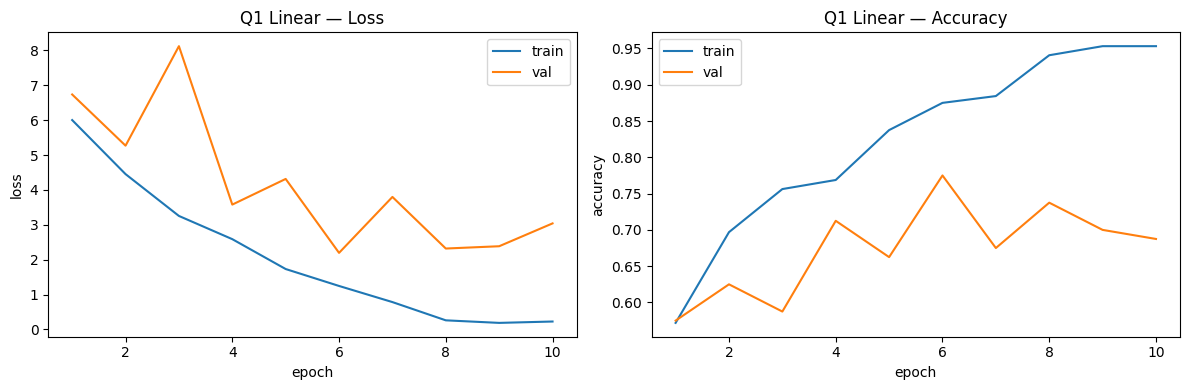


Q1 — Best validation top-1 accuracy: 0.7750


In [41]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_title("Q1 Linear — Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"],   label="val")
axes[1].set_title("Q1 Linear — Accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()


best_val_acc = max(history["val_acc"])
print(f"\nQ1 — Best validation top-1 accuracy: {best_val_acc:.4f}")


### 2. Q2 . Create a CNN with One Convolutional Block.
Resize to 128×128 , normalize; 
model: Conv2d(3→32, 3×3, padding=1) → MaxPool2d(2×2) → Flatten → Linear(num_classes) → Softmax . 
Keep the same preprocessing   as Q1.  

In [42]:
class CNNOneBlock(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(32 * (img_size // 2) * (img_size // 2), num_classes)

    def forward(self, x):
        x = self.pool(self.conv(x))
        return self.linear(self.flatten(x))

In [46]:
q2_model = CNNOneBlock()
# here i dont do any preprocessing because normalization in this step is the same as before

print(q2_model)
print(f"Parameters: {sum(p.numel() for p in q2_model.parameters()):,}")

CNNOneBlock(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=131072, out_features=2, bias=True)
)
Parameters: 263,042


### 3. Q3. Add Activation Functions to the Conv Block.  Insert ReLU  after the convolution:  
Conv2d (3→32, 3×3, padding=1)  → ReLU → MaxPool2d(2×2) → Flatten → Linear (to 
num_classes) → Softmax.

In [50]:
class CNNWithRELU(nn.Module):
    def __init__(self, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(32 * (img_size // 2) * (img_size // 2), num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [51]:
q3_model = CNNWithRELU()

In [52]:
print(q3_model)
print(f"Parameters: {sum(p.numel() for p in q3_model.parameters()):,}")

CNNWithRELU(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=131072, out_features=2, bias=True)
)
Parameters: 263,042


### 4. Q4. Forward Pass Classification.  
Use CrossEntropyLoss and SGD or Adam. Run a single forward/backward step on one mini -batch, confirm loss decreases on a few successive steps and that gradients/parameters update as expected. 

In [57]:
torch.manual_seed(SEED)
q4_model = CNNWithRELU()
q4_criterion = nn.CrossEntropyLoss()
q4_optimizer = torch.optim.Adam(q4_model.parameters(), lr=1e-5)

imgs_batch, labels_batch = next(iter(train_loader))

weights_before = q4_model.linear.weight.data.clone()
print(f"{'Step':>4}  {'Loss':>8}  {'Grads non-None':>14}  {'Weights changed':>15}")
print("-" * 50)

N_STEPS = 5
for step in range(1, N_STEPS + 1):
    q4_optimizer.zero_grad()
    outputs = q4_model(imgs_batch)
    loss    = q4_criterion(outputs, labels_batch)
    loss.backward()
    q4_optimizer.step()

    grads_ok = all(p.grad is not None for p in q4_model.parameters())
    weights_after = q4_model.linear.weight.data.clone()
    weights_moved = not torch.allclose(weights_before, weights_after)
    weights_before = weights_after

    print(f"{step:>4}  {loss.item():>8.4f}  {str(grads_ok):>14}  {str(weights_moved):>15}")

Step      Loss  Grads non-None  Weights changed
--------------------------------------------------
   1    0.6874            True             True
   2    0.6542            True             True
   3    0.6216            True             True
   4    0.5913            True             True
   5    0.5650            True             True


### 5. Q5. Train the CNN and Track Learning Curves . 
Train the Q3 model for 5 epochs; log train/val loss and accuracy per epoch; plot loss & accuracy vs. epochs; report the best validation accuracy. 

In [58]:
Q5_EPOCHS = 5

q5_model = CNNWithRELU()
q5_criterion = nn.CrossEntropyLoss()
q5_optimizer = torch.optim.Adam(q5_model.parameters(), lr=LR)

def run_epoch_q5(loader, train=True):
    q5_model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            outputs = q5_model(imgs)
            loss    = q5_criterion(outputs, labels)
            if train:
                q5_optimizer.zero_grad()
                loss.backward()
                q5_optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

In [59]:
history_q5 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, Q5_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_q5(train_loader, train=True)
    vl_loss, vl_acc = run_epoch_q5(val_loader,   train=False)
    history_q5["train_loss"].append(tr_loss)
    history_q5["val_loss"].append(vl_loss)
    history_q5["train_acc"].append(tr_acc)
    history_q5["val_acc"].append(vl_acc)
    print(f"Epoch {epoch}/{Q5_EPOCHS} | "
          f"train loss {tr_loss:.4f}  acc {tr_acc:.4f} | "
          f"val loss {vl_loss:.4f}  acc {vl_acc:.4f}")

Epoch 1/5 | train loss 7.7715  acc 0.5750 | val loss 10.5473  acc 0.5375
Epoch 2/5 | train loss 6.3792  acc 0.6344 | val loss 9.7056  acc 0.5375
Epoch 3/5 | train loss 4.3588  acc 0.6156 | val loss 5.5811  acc 0.5625
Epoch 4/5 | train loss 2.4959  acc 0.6844 | val loss 4.6753  acc 0.5625
Epoch 5/5 | train loss 1.6421  acc 0.7375 | val loss 2.8908  acc 0.6250


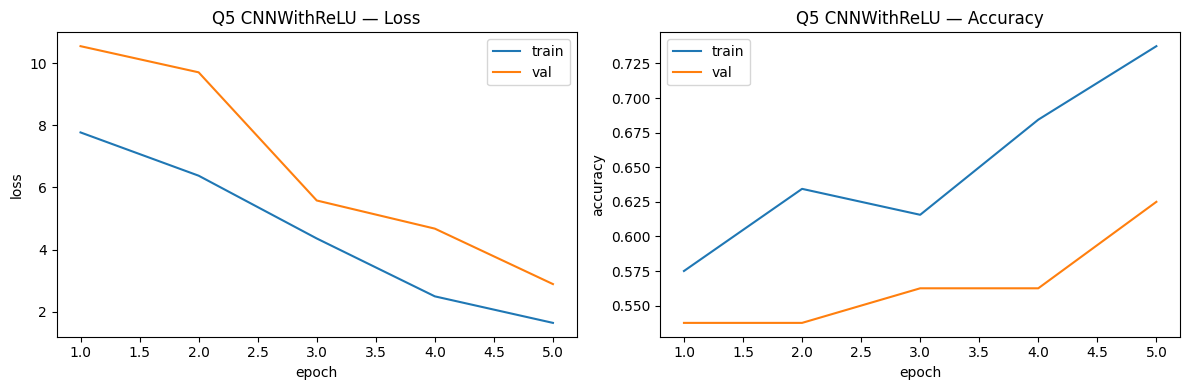


Q5 — Best validation top-1 accuracy: 0.6250 (62.50%)


In [60]:
epochs_range = range(1, Q5_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history_q5["train_loss"], label="train")
axes[0].plot(epochs_range, history_q5["val_loss"],   label="val")
axes[0].set_title("Q5 CNNWithReLU — Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(epochs_range, history_q5["train_acc"], label="train")
axes[1].plot(epochs_range, history_q5["val_acc"],   label="val")
axes[1].set_title("Q5 CNNWithReLU — Accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

best_val_acc_q5 = max(history_q5["val_acc"])
print(f"\nQ5 — Best validation top-1 accuracy: {best_val_acc_q5:.4f} ({best_val_acc_q5*100:.2f}%)")

### 6. Q6. Evaluate with Classification Metrics .  
On the val/test split, compute Top -1 accuracy ,  macro Precision/Recall/F1 , and a confusion matrix . Report per-class F1   and highlight the three weakest classes. ->> note for myself - we have only 2 classes total.

In [62]:
q5_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = q5_model(imgs)
        all_preds.extend(outputs.argmax(1).tolist())
        all_labels.extend(labels.tolist())

class_names = full_train_ds.classes

top1_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Top-1 Accuracy : {top1_acc:.4f} ({top1_acc*100:.2f}%)\n")

macro_p  = precision_score(all_labels, all_preds, average="macro")
macro_r  = recall_score   (all_labels, all_preds, average="macro")
macro_f1 = f1_score       (all_labels, all_preds, average="macro")
print(f"Macro Precision : {macro_p:.4f}")
print(f"Macro Recall    : {macro_r:.4f}")
print(f"Macro F1        : {macro_f1:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

per_class_f1 = f1_score(all_labels, all_preds, average=None)
sorted_classes = sorted(zip(per_class_f1, class_names))
print("Per-class F1 (weakest first):")
for f1, cls in sorted_classes:
    print(f"  {cls:<12} F1 = {f1:.4f}")

Top-1 Accuracy : 0.6250 (62.50%)

Macro Precision : 0.7451
Macro Recall    : 0.6335
Macro F1        : 0.5807

              precision    recall  f1-score   support

       bears       0.92      0.29      0.44        41
   elephants       0.57      0.97      0.72        39

    accuracy                           0.62        80
   macro avg       0.75      0.63      0.58        80
weighted avg       0.75      0.62      0.58        80

Per-class F1 (weakest first):
  bears        F1 = 0.4444
  elephants    F1 = 0.7170


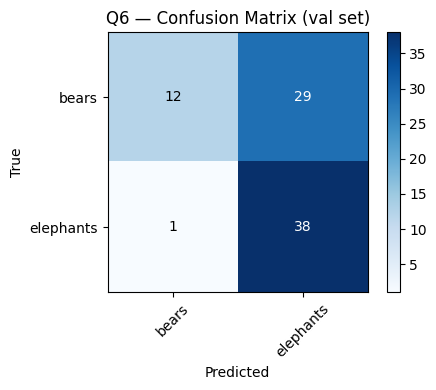

In [63]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Q6 — Confusion Matrix (val set)")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 7. Q7. Tiny Hyperparameter Grid .  
Grid: filters ∈  {32, 64}, lr ∈  {1e‑3, 3e‑4}, batch  ∈  {64, 128}, weight_decay ∈ {0, 1e‑4}. Train 3 epochs/config; select the model with the best macro‑F1 on validation.  

In [66]:
# configurable filters CNN
class CNNGrid(nn.Module):
    def __init__(self, filters=32, img_size=IMG_SIZE, num_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(filters * (img_size // 2) * (img_size // 2), num_classes),
        )
    def forward(self, x):
        return self.net(x)

In [68]:
# grid search
GRID = {
    "filters":       [32, 64],
    "lr":            [1e-3, 3e-4],
    "batch_size":    [64, 128],
    "weight_decay":  [0, 1e-4],
}
grid_keys   = list(GRID.keys())
grid_values = list(GRID.values())

In [69]:
results = []

for combo in itertools.product(*grid_values):
    cfg = dict(zip(grid_keys, combo))

    # dataloaders with this batch size
    tr_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True)
    vl_loader = DataLoader(val_ds,   batch_size=cfg["batch_size"])

    m   = CNNGrid(filters=cfg["filters"])
    opt = torch.optim.Adam(m.parameters(), lr=cfg["lr"],
                           weight_decay=cfg["weight_decay"])
    crit = nn.CrossEntropyLoss()

    # train
    m.train()
    for _ in range(3):
        for imgs, labels in tr_loader:
            opt.zero_grad()
            loss = crit(m(imgs), labels)
            loss.backward()
            opt.step()

    # eval macro-F1 on val
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, labels in vl_loader:
            preds.extend(m(imgs).argmax(1).tolist())
            trues.extend(labels.tolist())

    mf1 = f1_score(trues, preds, average="macro")
    results.append({"config": cfg, "macro_f1": mf1, "model": m})
    print(f"filters={cfg['filters']:2d}  lr={cfg['lr']:.0e}  "
          f"batch={cfg['batch_size']:3d}  wd={cfg['weight_decay']:.0e}  "
          f"macro-F1={mf1:.4f}")

# best conf by gridsearch
best = max(results, key=lambda r: r["macro_f1"])
best_model_q7 = best["model"]
print(f"\nBest config: {best['config']}")
print(f"Best macro-F1: {best['macro_f1']:.4f}")

filters=32  lr=1e-03  batch= 64  wd=0e+00  macro-F1=0.7367
filters=32  lr=1e-03  batch= 64  wd=1e-04  macro-F1=0.6983
filters=32  lr=1e-03  batch=128  wd=0e+00  macro-F1=0.6370
filters=32  lr=1e-03  batch=128  wd=1e-04  macro-F1=0.6190
filters=32  lr=3e-04  batch= 64  wd=0e+00  macro-F1=0.6075
filters=32  lr=3e-04  batch= 64  wd=1e-04  macro-F1=0.5528
filters=32  lr=3e-04  batch=128  wd=0e+00  macro-F1=0.3277
filters=32  lr=3e-04  batch=128  wd=1e-04  macro-F1=0.5726
filters=64  lr=1e-03  batch= 64  wd=0e+00  macro-F1=0.5330
filters=64  lr=1e-03  batch= 64  wd=1e-04  macro-F1=0.7341
filters=64  lr=1e-03  batch=128  wd=0e+00  macro-F1=0.4671
filters=64  lr=1e-03  batch=128  wd=1e-04  macro-F1=0.6277
filters=64  lr=3e-04  batch= 64  wd=0e+00  macro-F1=0.7367
filters=64  lr=3e-04  batch= 64  wd=1e-04  macro-F1=0.6444
filters=64  lr=3e-04  batch=128  wd=0e+00  macro-F1=0.5787
filters=64  lr=3e-04  batch=128  wd=1e-04  macro-F1=0.6612

Best config: {'filters': 32, 'lr': 0.001, 'batch_size':

### 8. Q8. Visual Diagnostics of Predictions .  
(a) Plot a row‑normalized confusion matrix heatmap ,  

(b) Show a 4×4 grid of validation images (8 correct, 8 incorrect) with true vs. predicted labels and 
predicted probabilities. Add brief notes on failure patterns (e.g., background bias, pose, scale). 

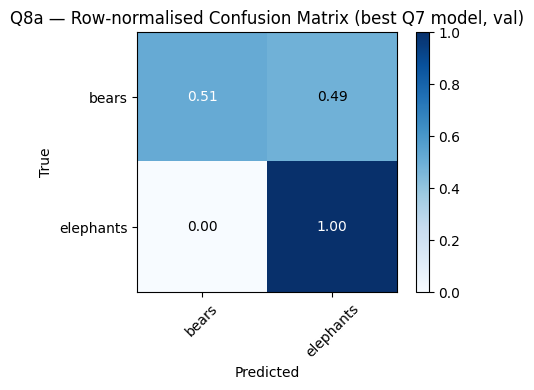

In [70]:
# row-norma CM
best_model_q7.eval()
val_loader_q8 = DataLoader(val_ds, batch_size=64, shuffle=False)

all_imgs_t, all_preds_q8, all_labels_q8, all_probs_q8 = [], [], [], []
with torch.no_grad():
    for imgs, labels in val_loader_q8:
        outputs = best_model_q7(imgs)
        probs   = torch.softmax(outputs, dim=1)
        all_imgs_t.append(imgs)
        all_preds_q8.extend(outputs.argmax(1).tolist())
        all_labels_q8.extend(labels.tolist())
        all_probs_q8.append(probs)

all_imgs_t   = torch.cat(all_imgs_t)
all_probs_q8 = torch.cat(all_probs_q8)

cm      = confusion_matrix(all_labels_q8, all_preds_q8)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Q8a — Row-normalised Confusion Matrix (best Q7 model, val)")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

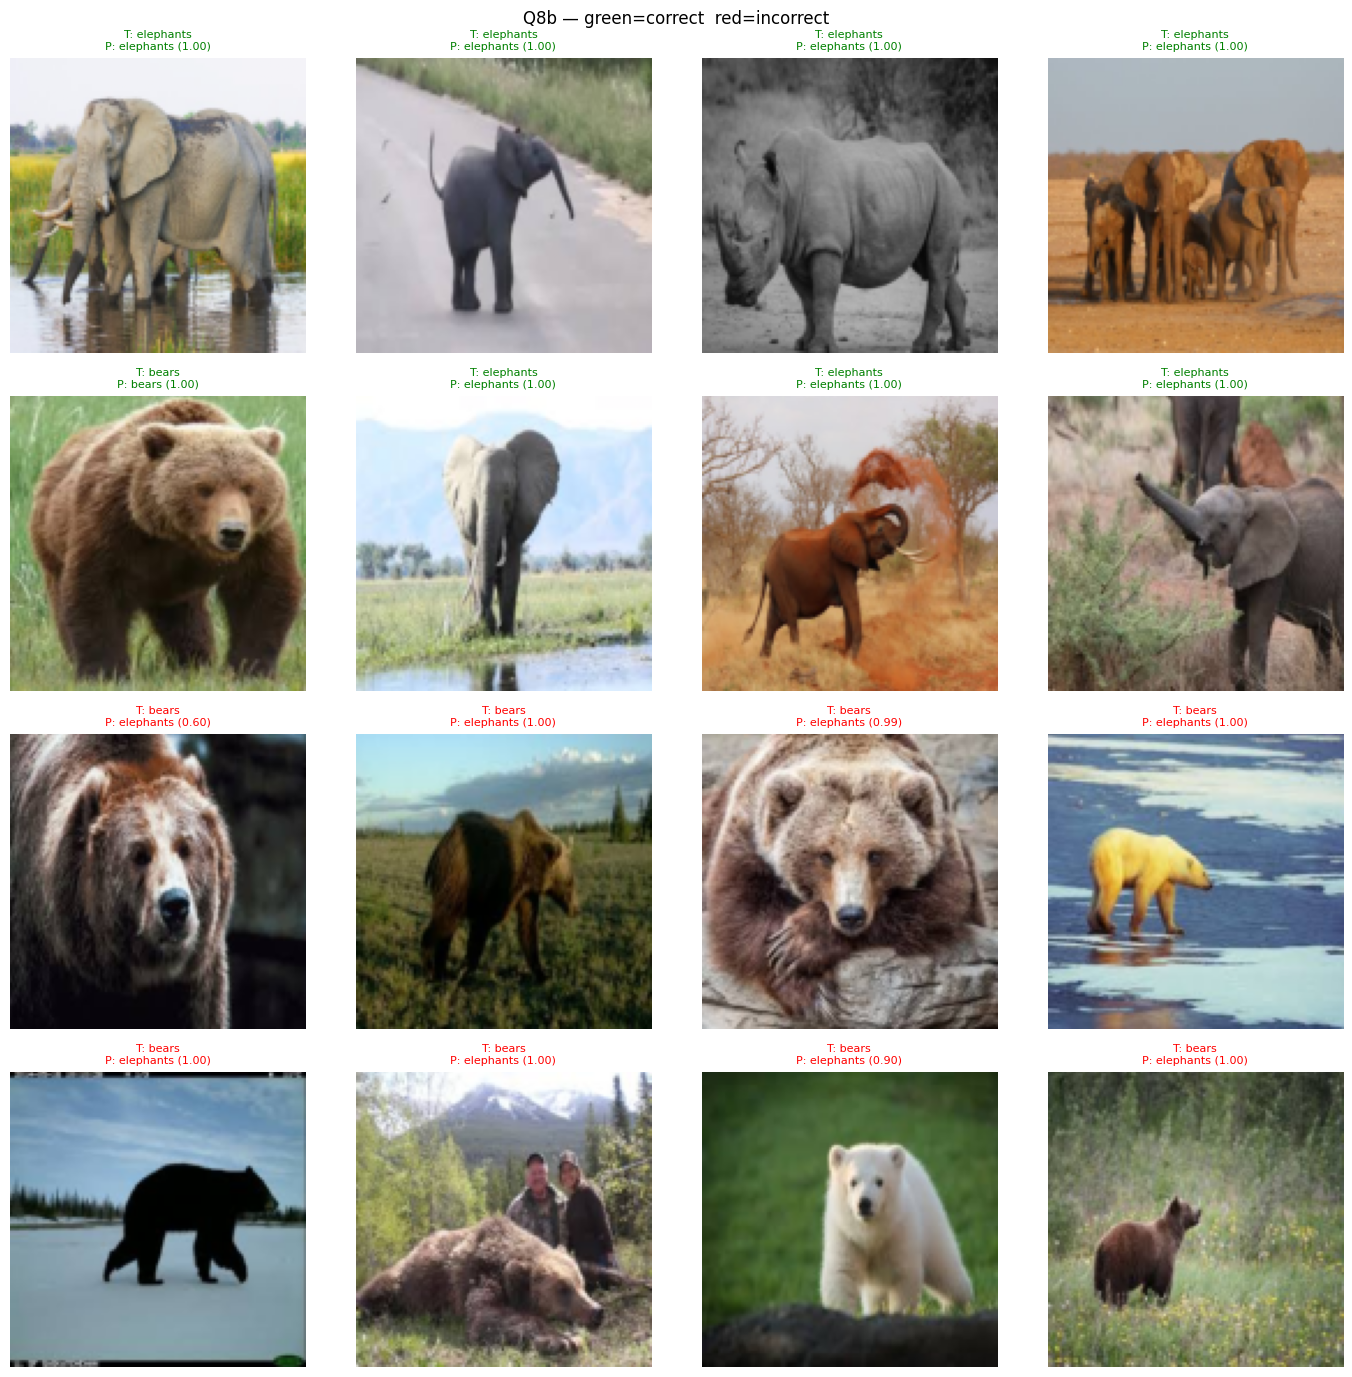

In [72]:
# val images
def unnormalize(t):
    mean = torch.tensor(MEAN_LIST).view(3,1,1)
    std  = torch.tensor(STD_LIST).view(3,1,1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

correct_idx   = [i for i,(p,l) in enumerate(zip(all_preds_q8, all_labels_q8)) if p == l]
incorrect_idx = [i for i,(p,l) in enumerate(zip(all_preds_q8, all_labels_q8)) if p != l]

chosen = correct_idx[:8] + incorrect_idx[:min(8, len(incorrect_idx))]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax in axes.ravel():
    ax.axis("off")

for plot_i, data_i in enumerate(chosen):
    img  = unnormalize(all_imgs_t[data_i])
    true = class_names[all_labels_q8[data_i]]
    pred = class_names[all_preds_q8[data_i]]
    prob = all_probs_q8[data_i][all_preds_q8[data_i]].item()
    axes.ravel()[plot_i].imshow(img)
    axes.ravel()[plot_i].set_title(
        f"T: {true}\nP: {pred} ({prob:.2f})",
        fontsize=8, color="green" if true == pred else "red"
    )

fig.suptitle("Q8b — green=correct  red=incorrect", fontsize=12)
plt.tight_layout()
plt.show()

Failure patterns:
- why non-elephant is classified as elephant (labeled) :)
- only bears are classified incorrectly 
- scale/crop - small and partially visible bears 
- pose - weird poses
- colors - too dark bears or white (not usual brown) bears
- bears with killers at background
- background bias -> sunny background gives bear unusual coloring

### 9. Q9. Inference Deliverable (Top - k Predictions)   
With the best model, run on a folder of unseen images (same preprocessing). Save a CSV with filename, top‑1 prediction, and top‑5 predictions with probabilities. Report throughput (img/s) on CPU/GPU.  

In [74]:
TOP_K      = min(5, NUM_CLASSES)
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model_q7.to(device).eval()

test_ds_q9 = ImageFolder(root=str(test_dir), transform=transform)
img_paths  = [s[0] for s in test_ds_q9.samples]   # absolute paths

csv_path   = BASE_DIR / "data/lab_2/q9_predictions.csv"
rows       = []

t0 = time.perf_counter()

with torch.no_grad():
    for img_path, (img_t, _) in zip(img_paths, test_ds_q9):
        img_t   = img_t.unsqueeze(0).to(device)          # (1, C, H, W)
        probs   = torch.softmax(best_model_q7(img_t), dim=1).squeeze()  # (num_classes,)
        topk_p, topk_i = probs.topk(TOP_K)

        top1_label = class_names[topk_i[0].item()]
        topk_str   = " | ".join(
            f"{class_names[idx.item()]}:{p.item():.4f}"
            for idx, p in zip(topk_i, topk_p)
        )
        rows.append({
            "filename": Path(img_path).name,
            "top1_prediction": top1_label,
            f"top{TOP_K}_predictions": topk_str,
        })

t1 = time.perf_counter()

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

n_imgs     = len(rows)
elapsed    = t1 - t0
throughput = n_imgs / elapsed

print(f"Processed  : {n_imgs} images")
print(f"Device     : {device}")
print(f"Time       : {elapsed:.3f} s")
print(f"Throughput : {throughput:.1f} img/s")
print(f"CSV saved  : {csv_path}\n")
print("Sample rows:")
for r in rows[:5]:
    print(f"  {r['filename']:<30}  top1={r['top1_prediction']:<10}  {r[f'top{TOP_K}_predictions']}")

Processed  : 40 images
Device     : cpu
Time       : 0.112 s
Throughput : 358.1 img/s
CSV saved  : /Users/sunsosun/Desktop/mini/ann/data/lab_2/q9_predictions.csv

Sample rows:
  k4 (71).jpg                     top1=bears       bears:0.9706 | elephants:0.0294
  k4 (72).jpeg                    top1=elephants   elephants:0.9973 | bears:0.0027
  k4 (72).jpg                     top1=elephants   elephants:0.9875 | bears:0.0125
  k4 (73).jpeg                    top1=elephants   elephants:1.0000 | bears:0.0000
  k4 (73).jpg                     top1=elephants   elephants:0.9875 | bears:0.0125


### 10. Q10. Explainability & Error Analysis . 
Show a small grid (e.g., 3×3) with 5 correct and 4 incorrect validation images. For each, display true vs. predicted and prediction confidence. Write 3 brief observations about failure patterns (e.g., background, pose, scale). 

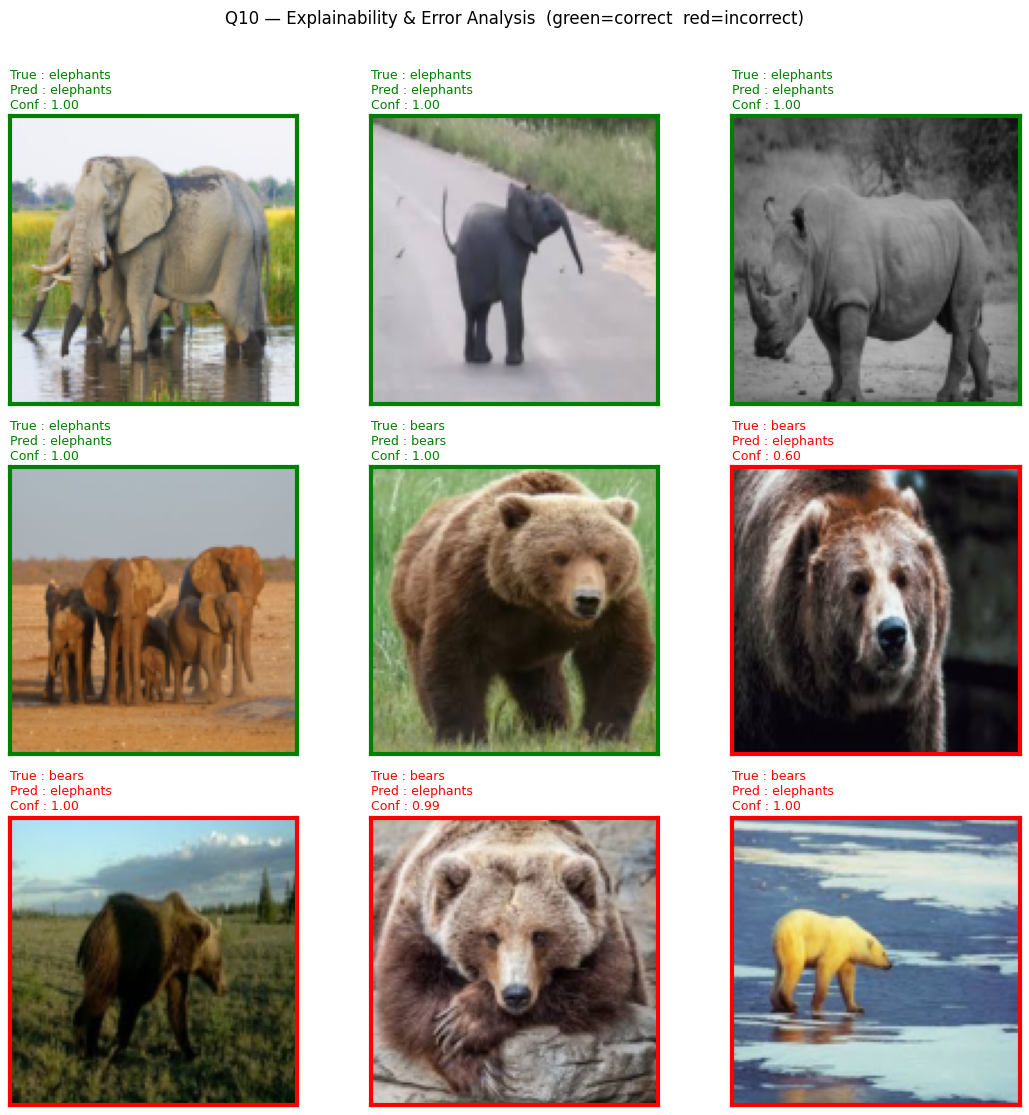

In [75]:
chosen_q10 = correct_idx[:5] + incorrect_idx[:4]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax in axes.ravel():
    ax.axis("off")

for plot_i, data_i in enumerate(chosen_q10):
    img        = unnormalize(all_imgs_t[data_i])
    true_label = class_names[all_labels_q8[data_i]]
    pred_label = class_names[all_preds_q8[data_i]]
    confidence = all_probs_q8[data_i][all_preds_q8[data_i]].item()
    correct    = true_label == pred_label

    ax = axes.ravel()[plot_i]
    ax.imshow(img)
    ax.set_title(
        f"True : {true_label}\nPred : {pred_label}\nConf : {confidence:.2f}",
        fontsize=9,
        color="green" if correct else "red",
        loc="left",
    )
    for spine in ax.spines.values():
        spine.set_edgecolor("green" if correct else "red")
        spine.set_linewidth(3)
    ax.axis("on")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Q10 — Explainability & Error Analysis  (green=correct  red=incorrect)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Failure pattern observations:
1. Background bias   — Bears photographed against dark, not clear or snowy backgrounds
are misclassified; the model appears to associate warm/neutral tones with elephants, likely because training images of elephants frequently appear in open, sunny scenes.

2. Scale & partial visibility — Incorrectly-predicted bears are dark or heavily cropped/zoomed in the frame. With only one MaxPool layer the receptive field is limited, so a half-visible animal lacks the global shape cue the model relies on.

3. Unusual pose / colour — White or very dark bears (polar-bear-like or back-lit) fall outside the brown-fur distribution the filter learned.  High prediction confidence (~0.9+) on wrong predictions indicates the model is overconfident and not well-calibrated on edge cases.

### 11. Additional - best mdel with best config but trained on biggere amount of epochs.

In [79]:
EXTRA_EPOCHS = 30
PATIENCE     = 5 # earlt stop
best_cfg = best["config"]

tr_loader_11 = DataLoader(train_ds, batch_size=best_cfg["batch_size"], shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
vl_loader_11 = DataLoader(val_ds, batch_size=best_cfg["batch_size"])

torch.manual_seed(SEED)
model_11 = CNNGrid(filters=best_cfg["filters"])
opt_11   = torch.optim.Adam(model_11.parameters(), lr=best_cfg["lr"],
                             weight_decay=best_cfg["weight_decay"])
crit_11  = nn.CrossEntropyLoss()

history_11 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss_11  = float("inf")
best_model_state  = None
epochs_no_improve = 0
stopped_epoch     = EXTRA_EPOCHS

for epoch in range(1, EXTRA_EPOCHS + 1):
    model_11.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, labels in tr_loader_11:
        opt_11.zero_grad()
        out  = model_11(imgs)
        loss = crit_11(out, labels)
        loss.backward()
        opt_11.step()
        t_loss    += loss.item() * len(labels)
        t_correct += (out.argmax(1) == labels).sum().item()
        t_total   += len(labels)

    model_11.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in vl_loader_11:
            out  = model_11(imgs)
            loss = crit_11(out, labels)
            v_loss    += loss.item() * len(labels)
            v_correct += (out.argmax(1) == labels).sum().item()
            v_total   += len(labels)

    tr_l, tr_a = t_loss/t_total, t_correct/t_total
    vl_l, vl_a = v_loss/v_total, v_correct/v_total
    history_11["train_loss"].append(tr_l)
    history_11["val_loss"].append(vl_l)
    history_11["train_acc"].append(tr_a)
    history_11["val_acc"].append(vl_a)

    # early stopping check
    if vl_l < best_val_loss_11:
        best_val_loss_11  = vl_l
        best_model_state  = {k: v.clone() for k, v in model_11.state_dict().items()}
        epochs_no_improve = 0
        tag = "  ✓ best"
    else:
        epochs_no_improve += 1
        tag = f"  (no improve {epochs_no_improve}/{PATIENCE})"

    print(f"Epoch {epoch:3d}/{EXTRA_EPOCHS} | "
          f"train loss {tr_l:.4f}  acc {tr_a:.4f} | "
          f"val loss {vl_l:.4f}  acc {vl_a:.4f}{tag}")

    if epochs_no_improve >= PATIENCE:
        stopped_epoch = epoch
        print(f"\nEarly stopping at epoch {epoch} (no val loss improvement for {PATIENCE} epochs).")
        break

model_11.load_state_dict(best_model_state)
print(f"\nBest config   : {best_cfg}")
print(f"Stopped epoch : {stopped_epoch}")
print(f"Best val loss : {best_val_loss_11:.4f}")
print(f"Best val acc  : {max(history_11['val_acc']):.4f}")

Epoch   1/30 | train loss 4.4720  acc 0.6125 | val loss 4.7340  acc 0.5625  ✓ best
Epoch   2/30 | train loss 2.2764  acc 0.7281 | val loss 1.6508  acc 0.6750  ✓ best
Epoch   3/30 | train loss 1.6011  acc 0.7562 | val loss 2.8525  acc 0.6500  (no improve 1/5)
Epoch   4/30 | train loss 0.6104  acc 0.8844 | val loss 1.8742  acc 0.7125  (no improve 2/5)
Epoch   5/30 | train loss 0.5348  acc 0.8656 | val loss 1.1431  acc 0.7000  ✓ best
Epoch   6/30 | train loss 0.1599  acc 0.9375 | val loss 0.9721  acc 0.7625  ✓ best
Epoch   7/30 | train loss 0.1307  acc 0.9594 | val loss 1.2520  acc 0.7750  (no improve 1/5)
Epoch   8/30 | train loss 0.0714  acc 0.9750 | val loss 1.0063  acc 0.7875  (no improve 2/5)
Epoch   9/30 | train loss 0.0515  acc 0.9875 | val loss 1.2866  acc 0.7250  (no improve 3/5)
Epoch  10/30 | train loss 0.0494  acc 0.9875 | val loss 1.2384  acc 0.7500  (no improve 4/5)
Epoch  11/30 | train loss 0.0422  acc 0.9906 | val loss 1.3912  acc 0.7250  (no improve 5/5)

Early stopping a

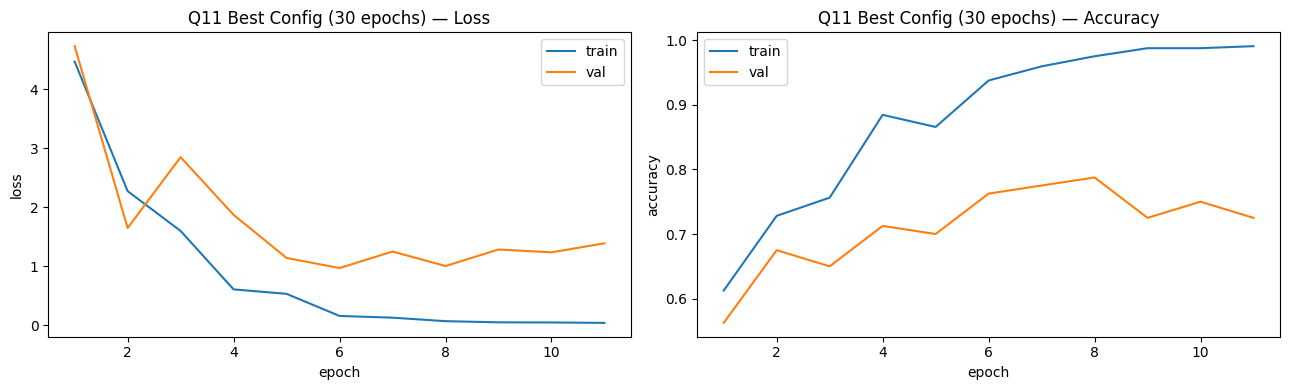

Macro F1 (Q7 best, 30 ep): 0.7595
Macro F1 (Q7 best, 3 ep)             : 0.7367

              precision    recall  f1-score   support

       bears       0.73      0.85      0.79        41
   elephants       0.81      0.67      0.73        39

    accuracy                           0.76        80
   macro avg       0.77      0.76      0.76        80
weighted avg       0.77      0.76      0.76        80



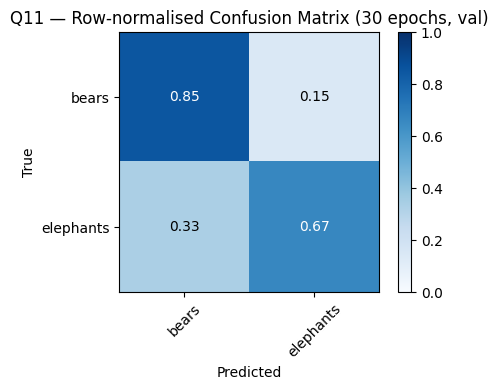

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history_11["train_loss"]) + 1)
axes[0].plot(ep, history_11["train_loss"], label="train")
axes[0].plot(ep, history_11["val_loss"],   label="val")
axes[0].set_title(f"Q11 Best Config ({EXTRA_EPOCHS} epochs) — Loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(ep, history_11["train_acc"], label="train")
axes[1].plot(ep, history_11["val_acc"],   label="val")
axes[1].set_title(f"Q11 Best Config ({EXTRA_EPOCHS} epochs) — Accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

model_11.eval()
preds_11, labels_11, probs_11, imgs_11 = [], [], [], []
with torch.no_grad():
    for imgs, labels in DataLoader(val_ds, batch_size=64, shuffle=False):
        out = model_11(imgs)
        p   = torch.softmax(out, dim=1)
        preds_11.extend(out.argmax(1).tolist())
        labels_11.extend(labels.tolist())
        probs_11.append(p)
        imgs_11.append(imgs)

probs_11 = torch.cat(probs_11)
imgs_11  = torch.cat(imgs_11)

mf1_11  = f1_score(labels_11, preds_11, average="macro")
per_f1  = f1_score(labels_11, preds_11, average=None)
print(f"Macro F1 (Q7 best, {EXTRA_EPOCHS} ep): {mf1_11:.4f}")
print(f"Macro F1 (Q7 best, 3 ep)             : {best['macro_f1']:.4f}")
print()
print(classification_report(labels_11, preds_11, target_names=class_names))

cm_11      = confusion_matrix(labels_11, preds_11)
cm_11_norm = cm_11.astype(float) / cm_11.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_11_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Q11 — Row-normalised Confusion Matrix ({EXTRA_EPOCHS} epochs, val)")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm_11_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_11_norm[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

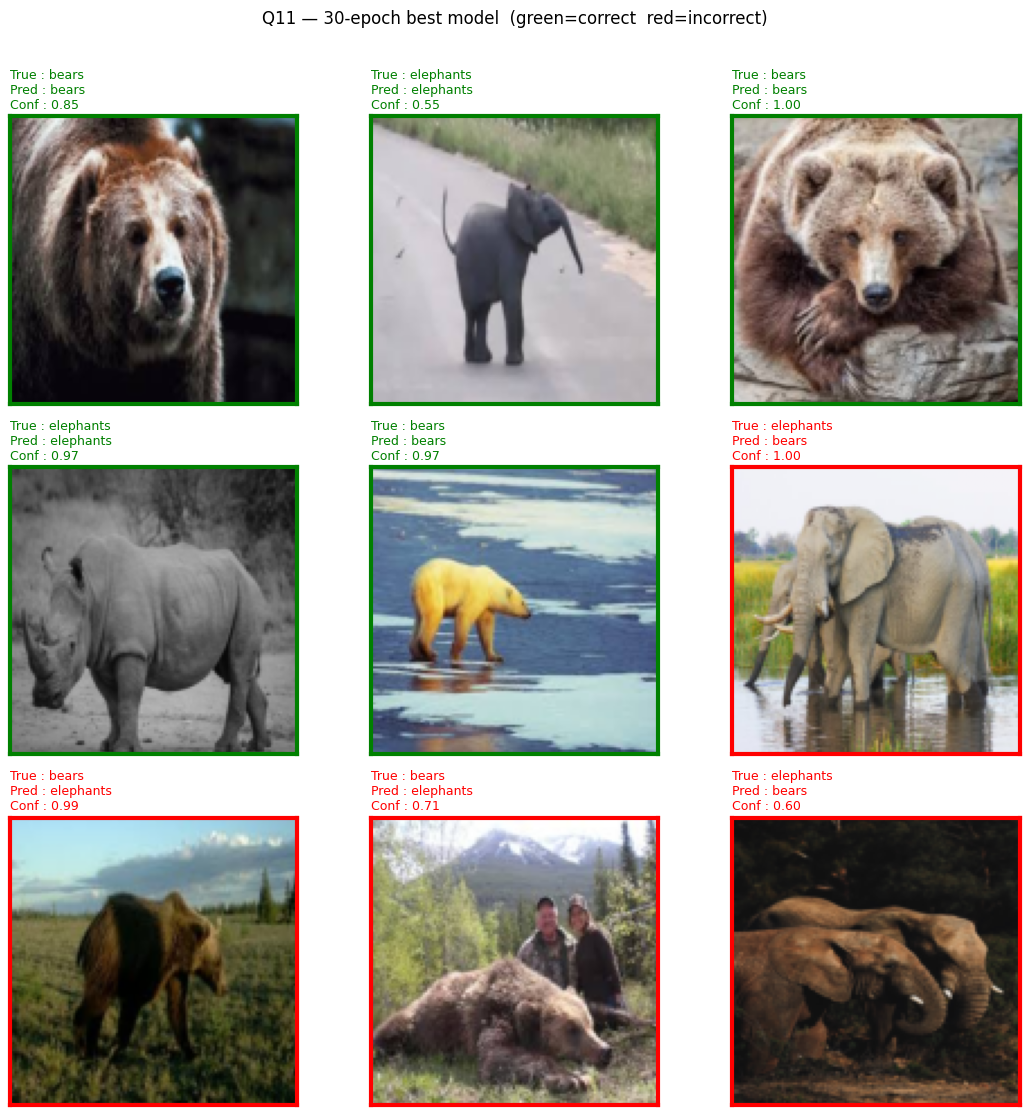

In [83]:
correct_11   = [i for i,(p,l) in enumerate(zip(preds_11, labels_11)) if p == l]
incorrect_11 = [i for i,(p,l) in enumerate(zip(preds_11, labels_11)) if p != l]

chosen_11 = correct_11[:5] + incorrect_11[:4]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax in axes.ravel():
    ax.axis("off")

for plot_i, data_i in enumerate(chosen_11):
    img = unnormalize(imgs_11[data_i])
    true_label = class_names[labels_11[data_i]]
    pred_label = class_names[preds_11[data_i]]
    confidence = probs_11[data_i][preds_11[data_i]].item()
    correct = true_label == pred_label

    ax = axes.ravel()[plot_i]
    ax.imshow(img)
    ax.set_title(
        f"True : {true_label}\nPred : {pred_label}\nConf : {confidence:.2f}",
        fontsize=9,
        color="green" if correct else "red",
        loc="left",
    )
    for spine in ax.spines.values():
        spine.set_edgecolor("green" if correct else "red")
        spine.set_linewidth(3)
    ax.axis("on")
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    f"Q11 — {EXTRA_EPOCHS}-epoch best model  (green=correct  red=incorrect)",
    fontsize=12, y=1.01
)
plt.tight_layout(); plt.show()